# ChurnSense-AI — 02 Exploratory Data Analysis (EDA)

**Goal:** Understand customer behavior, churn patterns, and retention opportunities before modeling.

**Input:** `data/processed/telco_churn_clean.csv` (from `01_data_cleaning.ipynb`)

**Outputs:** Business insights for dashboards, SQL analytics, and feature engineering.

---
Each chart section ends with **Insights** and **Retention actions** you can use in interviews and stakeholder decks.

## 1. Setup and load cleaned data

In [11]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

PALETTE = {"No": "#2ecc71", "Yes": "#e74c3c"}
CHURN_ORDER = ["No", "Yes"]

# Resolve project paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

CLEAN_PATH = PROJECT_ROOT / "data" / "processed" / "telco_churn_clean.csv"
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\MOHAMMED IMAD\Projects\ChurnSense-AI


In [13]:
def load_churn_data() -> pd.DataFrame:
    """Load cleaned data; fall back to raw + minimal TotalCharges fix if needed."""
    if CLEAN_PATH.exists():
        data = pd.read_csv(CLEAN_PATH)
        print(f"Loaded cleaned file: {CLEAN_PATH.name}")
        return data

    if not RAW_PATH.exists():
        raise FileNotFoundError(
            "No data found. Run 01_data_cleaning.ipynb or place the Kaggle CSV in data/raw/."
        )

    print("Cleaned file not found — loading raw and applying quick TotalCharges fix.")
    data = pd.read_csv(RAW_PATH)
    data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
    data["TotalCharges"] = data["TotalCharges"].fillna(data["MonthlyCharges"])
    return data


df = load_churn_data()

# Binary target for correlations and rates
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Loaded cleaned file: telco_churn_clean.csv
Shape: 7,043 rows × 22 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1


In [14]:
def churn_rate_table(frame: pd.DataFrame, column: str) -> pd.DataFrame:
    """Churn count and churn rate (%) by category."""
    summary = (
        frame.groupby(column, observed=True)
        .agg(customers=("Churn", "size"), churners=("ChurnFlag", "sum"))
        .assign(churn_rate_pct=lambda x: (x["churners"] / x["customers"] * 100).round(2))
        .sort_values("churn_rate_pct", ascending=False)
    )
    return summary


def plot_churn_rate_bar(frame: pd.DataFrame, column: str, title: str, top_n: int | None = None):
    """Horizontal bar chart of churn rate by category."""
    rates = churn_rate_table(frame, column)["churn_rate_pct"]
    if top_n:
        rates = rates.head(top_n)

    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(rates))))
    rates.sort_values().plot(kind="barh", ax=ax, color="#3498db", edgecolor="white")
    ax.axvline(frame["ChurnFlag"].mean() * 100, color="#e74c3c", linestyle="--", label="Overall churn %")
    ax.set_xlabel("Churn rate (%)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

    return rates

## 2. Churn distribution (target variable)

In [15]:
churn_counts = df["Churn"].value_counts().reindex(CHURN_ORDER)
churn_pct = (churn_counts / churn_counts.sum() * 100).round(2)

print("Churn counts:")
print(churn_counts)
print(f"\nOverall churn rate: {df['ChurnFlag'].mean():.2%}")

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Overall churn rate: 26.54%


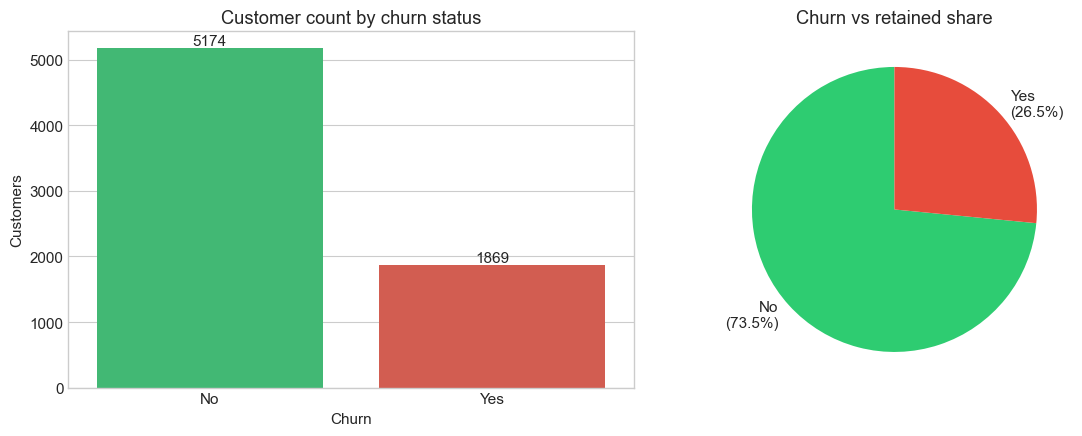

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Count plot
sns.countplot(data=df, x="Churn", order=CHURN_ORDER, palette=PALETTE, ax=axes[0])
axes[0].set_title("Customer count by churn status")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Customers")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d")

# Pie chart — share of base
axes[1].pie(
    churn_counts,
    labels=[f"{idx}\n({churn_pct[idx]:.1f}%)" for idx in churn_counts.index],
    colors=[PALETTE[k] for k in churn_counts.index],
    autopct="",
    startangle=90,
)
axes[1].set_title("Churn vs retained share")

plt.tight_layout()
plt.show()

### Insights — churn distribution

- Roughly **1 in 4 customers churns** in this dataset (class imbalance: more "No" than "Yes").
- For modeling we should **not rely on accuracy alone** — a model predicting "no churn" for everyone would look deceptively good.

### Retention actions

- Define KPIs around **churn rate %** and **retained revenue**, not only model accuracy.
- Plan **proactive outreach** for the ~26% at-risk segment (or your exact rate after running the notebook).

## 3. Customer demographics

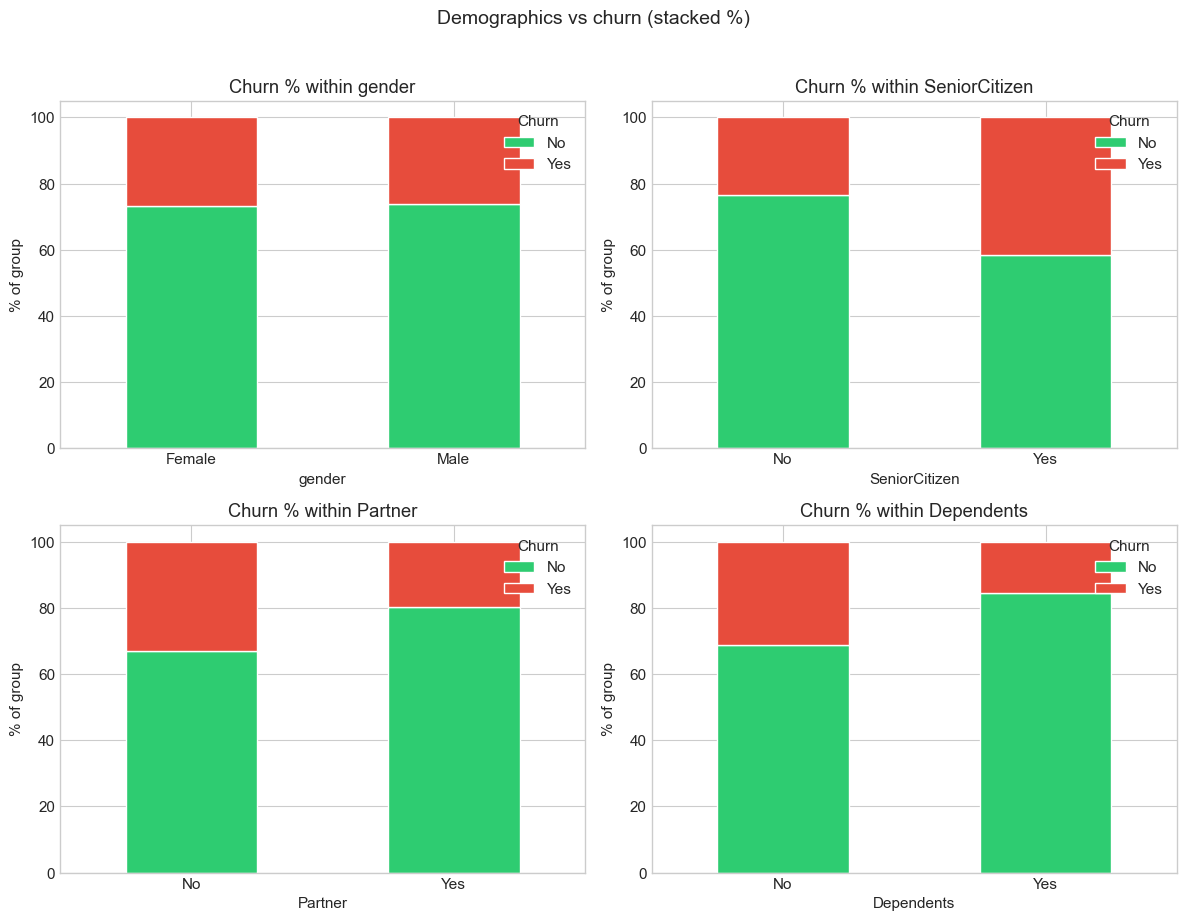

In [17]:
demo_cols = ["gender", "SeniorCitizen", "Partner", "Dependents"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, col in zip(axes, demo_cols):
    if col == "SeniorCitizen":
        plot_df = df.copy()
        plot_df["SeniorCitizen"] = plot_df["SeniorCitizen"].map({0: "No", 1: "Yes"})
    else:
        plot_df = df

    ct = pd.crosstab(plot_df[col], plot_df["Churn"], normalize="index") * 100
    ct = ct.reindex(columns=CHURN_ORDER)
    ct.plot(kind="bar", stacked=True, ax=ax, color=[PALETTE[c] for c in CHURN_ORDER], edgecolor="white")
    ax.set_title(f"Churn % within {col}")
    ax.set_ylabel("% of group")
    ax.set_xlabel(col)
    ax.legend(title="Churn", loc="upper right")
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Demographics vs churn (stacked %)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
for col in demo_cols:
    label_col = col
    temp = df.copy()
    if col == "SeniorCitizen":
        temp[col] = temp[col].map({0: "Non-senior", 1: "Senior"})
    print(f"\n=== Churn rate by {col} ===")
    display(churn_rate_table(temp, col))


=== Churn rate by gender ===


,customers,churners,churn_rate_pct
gender,,,
Female,3488,939,26.92
Male,3555,930,26.16



=== Churn rate by SeniorCitizen ===


,customers,churners,churn_rate_pct
SeniorCitizen,,,
Senior,1142,476,41.68
Non-senior,5901,1393,23.61



=== Churn rate by Partner ===


,customers,churners,churn_rate_pct
Partner,,,
No,3641,1200,32.96
Yes,3402,669,19.66



=== Churn rate by Dependents ===


,customers,churners,churn_rate_pct
Dependents,,,
No,4933,1543,31.28
Yes,2110,326,15.45


### Insights — demographics

- **Senior citizens** typically show **higher churn rates** than non-seniors — often linked to price sensitivity, support needs, or simpler plan preferences.
- Customers **without partners or dependents** tend to churn more — fewer household "anchors" to the provider.
- **Gender** differences are usually **small**; churn strategy should not over-index on gender alone.

### Retention actions

- **Senior loyalty programs**: discounted bundles, dedicated support, paper billing options if preferred.
- **Single-account offers**: family/add-a-line promos for customers with no Partner/Dependents.

## 4. Tenure analysis (customer lifetime)

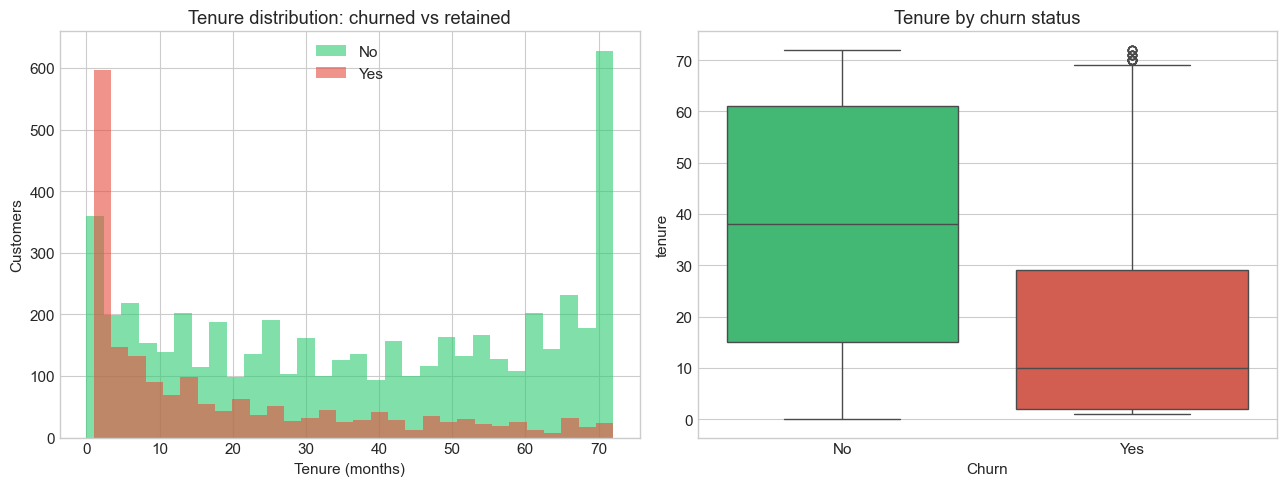

Tenure summary by churn:


,mean,median,min,max
Churn,,,,
No,37.6,38.0,0,72
Yes,18.0,10.0,1,72


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution by churn
for churn_label in CHURN_ORDER:
    subset = df.loc[df["Churn"] == churn_label, "tenure"]
    axes[0].hist(subset, bins=30, alpha=0.6, label=churn_label, color=PALETTE[churn_label])
axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Customers")
axes[0].set_title("Tenure distribution: churned vs retained")
axes[0].legend()

# Box plot
sns.boxplot(data=df, x="Churn", y="tenure", order=CHURN_ORDER, palette=PALETTE, ax=axes[1])
axes[1].set_title("Tenure by churn status")

plt.tight_layout()
plt.show()

print("Tenure summary by churn:")
display(df.groupby("Churn")["tenure"].agg(["mean", "median", "min", "max"]).round(1))

,customers,churners,churn_rate_pct
TenureGroup,,,
0-6 mo,1470,784,53.33
7-12 mo,705,253,35.89
13-24 mo,1024,294,28.71
25-48 mo,1594,325,20.39
49-72 mo,2239,213,9.51


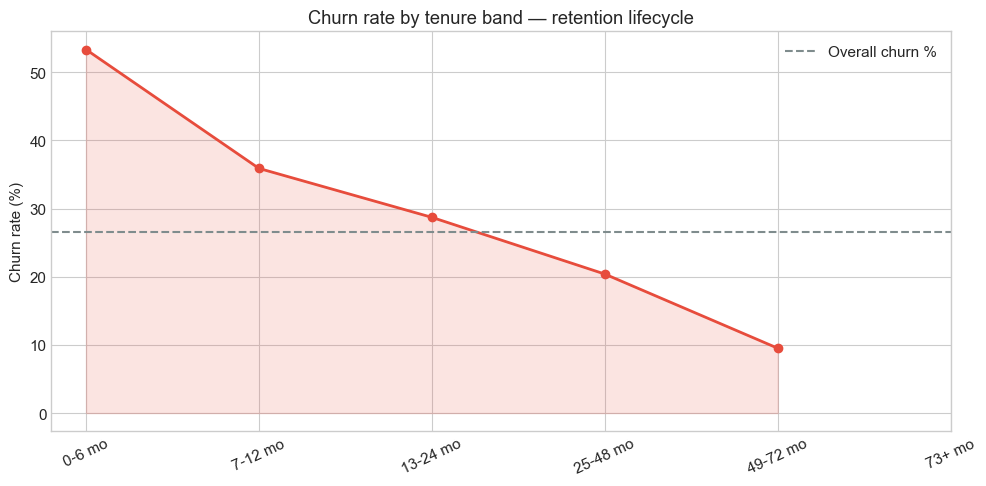

In [20]:
# Binned tenure — churn rate trend
tenure_bins = [0, 6, 12, 24, 48, 72, df["tenure"].max() + 1]
tenure_labels = ["0-6 mo", "7-12 mo", "13-24 mo", "25-48 mo", "49-72 mo", "73+ mo"]

df["TenureGroup"] = pd.cut(df["tenure"], bins=tenure_bins, labels=tenure_labels, right=True)

tenure_churn = churn_rate_table(df, "TenureGroup")
display(tenure_churn)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(tenure_labels))
ax.plot(x, tenure_churn.reindex(tenure_labels)["churn_rate_pct"], marker="o", linewidth=2, color="#e74c3c")
ax.fill_between(x, tenure_churn.reindex(tenure_labels)["churn_rate_pct"], alpha=0.15, color="#e74c3c")
ax.axhline(df["ChurnFlag"].mean() * 100, linestyle="--", color="#7f8c8d", label="Overall churn %")
ax.set_xticks(x)
ax.set_xticklabels(tenure_labels, rotation=25)
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn rate by tenure band — retention lifecycle")
ax.legend()
plt.tight_layout()
plt.show()

### Insights — tenure

- **Churned customers have much lower median tenure** — many leave in the **first year**.
- Churn rate is usually **highest in months 0–12**, then **falls** as tenure increases (loyalty effect).
- The **first 90 days** are a critical onboarding window (aligns with Chang et al. and industry practice).

### Retention actions

- **Onboarding program**: welcome calls, setup help, first-bill review at month 1–3.
- **Early-life triggers**: flag tenure &lt; 12 months in CRM for proactive retention campaigns.

## 5. Monthly charges analysis

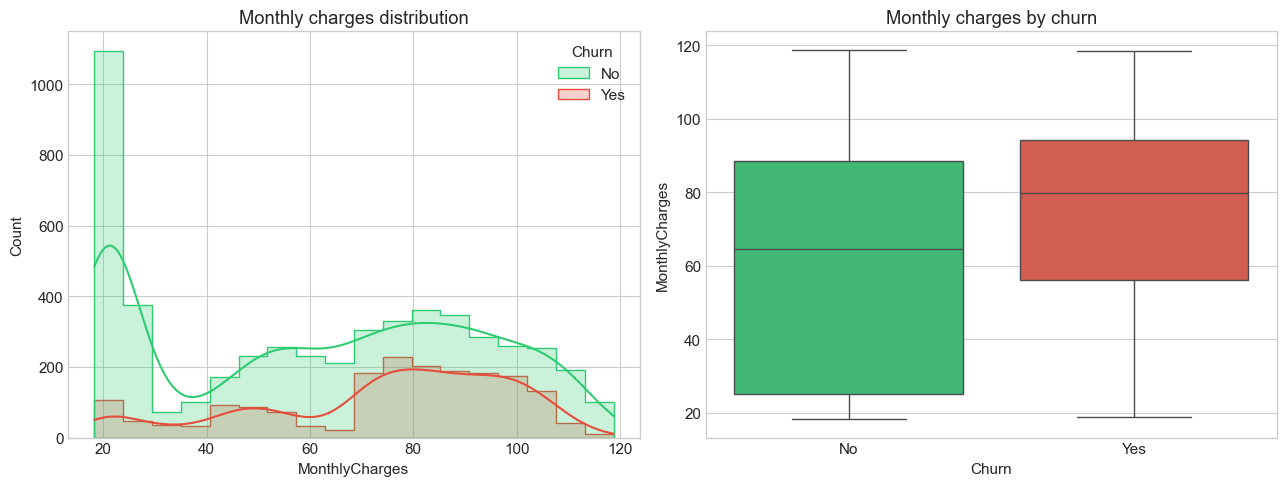

,mean,median,std
Churn,,,
No,61.27,64.43,31.09
Yes,74.44,79.65,24.67


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(data=df, x="MonthlyCharges", hue="Churn", hue_order=CHURN_ORDER,
             palette=PALETTE, kde=True, element="step", ax=axes[0])
axes[0].set_title("Monthly charges distribution")

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", order=CHURN_ORDER, palette=PALETTE, ax=axes[1])
axes[1].set_title("Monthly charges by churn")

plt.tight_layout()
plt.show()

display(df.groupby("Churn")["MonthlyCharges"].agg(["mean", "median", "std"]).round(2))

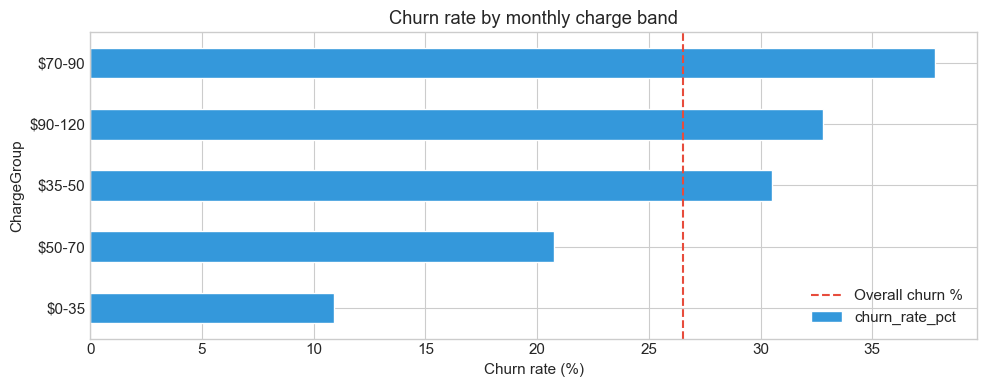

,customers,churners,churn_rate_pct
ChargeGroup,,,
$70-90,1844,697,37.80
$90-120,1739,570,32.78
$35-50,564,172,30.50
$50-70,1161,241,20.76
$0-35,1735,189,10.89


In [24]:
charge_bins = [0, 35, 50, 70, 90, 120, df["MonthlyCharges"].max() + 1]
charge_labels = ["$0-35", "$35-50", "$50-70", "$70-90", "$90-120", "$120+"]
last_bin = max(120, df["MonthlyCharges"].max()) + 1
charge_bins = [0, 35, 50, 70, 90, 120, last_bin]
charge_labels = ["$0-35", "$35-50", "$50-70", "$70-90", "$90-120", "$120+"]
df["ChargeGroup"] = pd.cut(df["MonthlyCharges"], bins=charge_bins, labels=charge_labels)

plot_churn_rate_bar(df, "ChargeGroup", "Churn rate by monthly charge band")
display(churn_rate_table(df, "ChargeGroup"))

### Insights — monthly charges

- Churned customers often pay **higher monthly charges** on average — possible **price fatigue** or upsell without perceived value.
- **Mid-to-high price tiers** frequently show elevated churn — customers may shop competitors when bills rise.

### Retention actions

- **Value messaging** for high-MRC accounts: usage reports, loyalty credits, plan optimization.
- **Price increase guardrails**: review hikes for customers in high charge bands with low tenure.

## 6. Contract type analysis

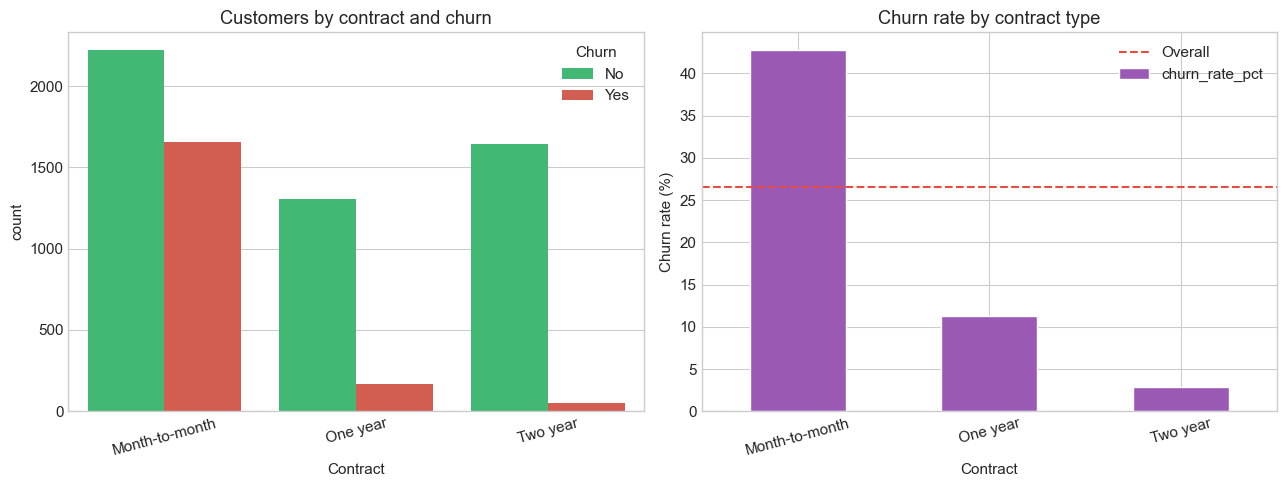

,customers,churners,churn_rate_pct
Contract,,,
Month-to-month,3875,1655,42.71
One year,1473,166,11.27
Two year,1695,48,2.83


In [25]:
contract_order = ["Month-to-month", "One year", "Two year"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x="Contract", order=contract_order, hue="Churn",
              hue_order=CHURN_ORDER, palette=PALETTE, ax=axes[0])
axes[0].set_title("Customers by contract and churn")
axes[0].tick_params(axis="x", rotation=15)

rates = churn_rate_table(df, "Contract").reindex(contract_order)
rates["churn_rate_pct"].plot(kind="bar", ax=axes[1], color="#9b59b6", edgecolor="white")
axes[1].axhline(df["ChurnFlag"].mean() * 100, color="#e74c3c", linestyle="--", label="Overall")
axes[1].set_title("Churn rate by contract type")
axes[1].set_ylabel("Churn rate (%)")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()
display(rates)

### Insights — contract type

- **Month-to-month** contracts dominate churn — **low switching cost**, easy exit.
- **Two-year** contracts usually have the **lowest churn rate** — commitment locks customers in.
- This is often the **#1 business lever** in telecom churn studies (including the reference paper's SHAP results).

### Retention actions

- **Migrate MTM → annual/2-year** with incentives (discount, free upgrade, waived fees).
- **Early renewal offers** 60–90 days before contract end for one-year customers.

## 7. Payment method analysis

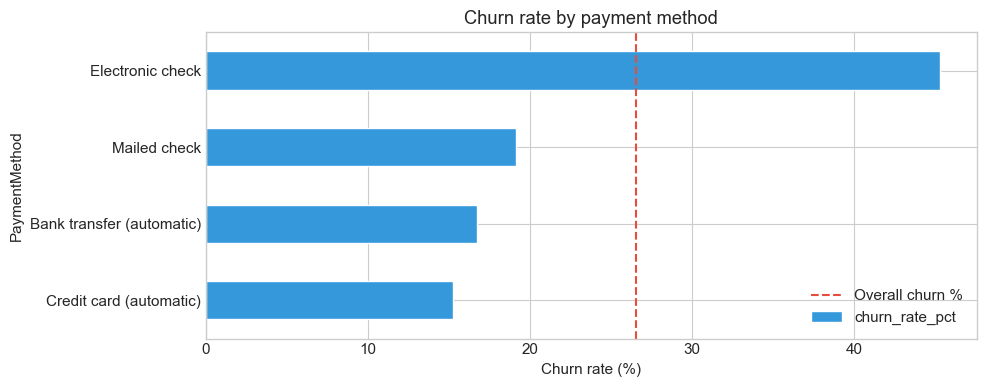

,customers,churners,churn_rate_pct
PaymentMethod,,,
Electronic check,2365,1071,45.29
Mailed check,1612,308,19.11
Bank transfer (automatic),1544,258,16.71
Credit card (automatic),1522,232,15.24


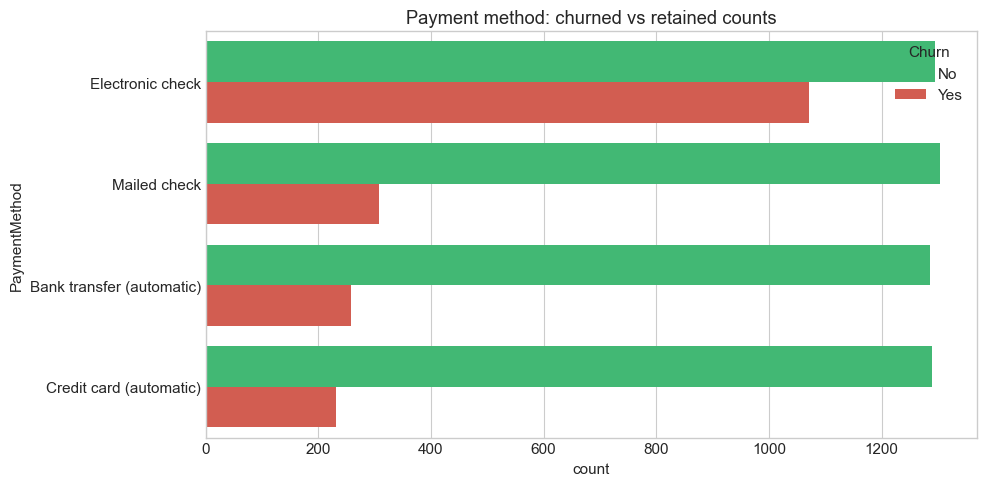

In [26]:
payment_rates = plot_churn_rate_bar(df, "PaymentMethod", "Churn rate by payment method")
display(churn_rate_table(df, "PaymentMethod"))

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, y="PaymentMethod", hue="Churn", hue_order=CHURN_ORDER, palette=PALETTE, ax=ax)
ax.set_title("Payment method: churned vs retained counts")
plt.tight_layout()
plt.show()

### Insights — payment method

- **Electronic check** and **Mailed check** users often churn **more** than auto-pay (credit card / bank transfer).
- Manual payment friction → missed payments → dissatisfaction → churn.

### Retention actions

- Promote **autopay discounts** for check payers.
- **Payment failure outreach** before suspension (SMS + easy pay link).

## 8. Service & product mix (telecom-specific)

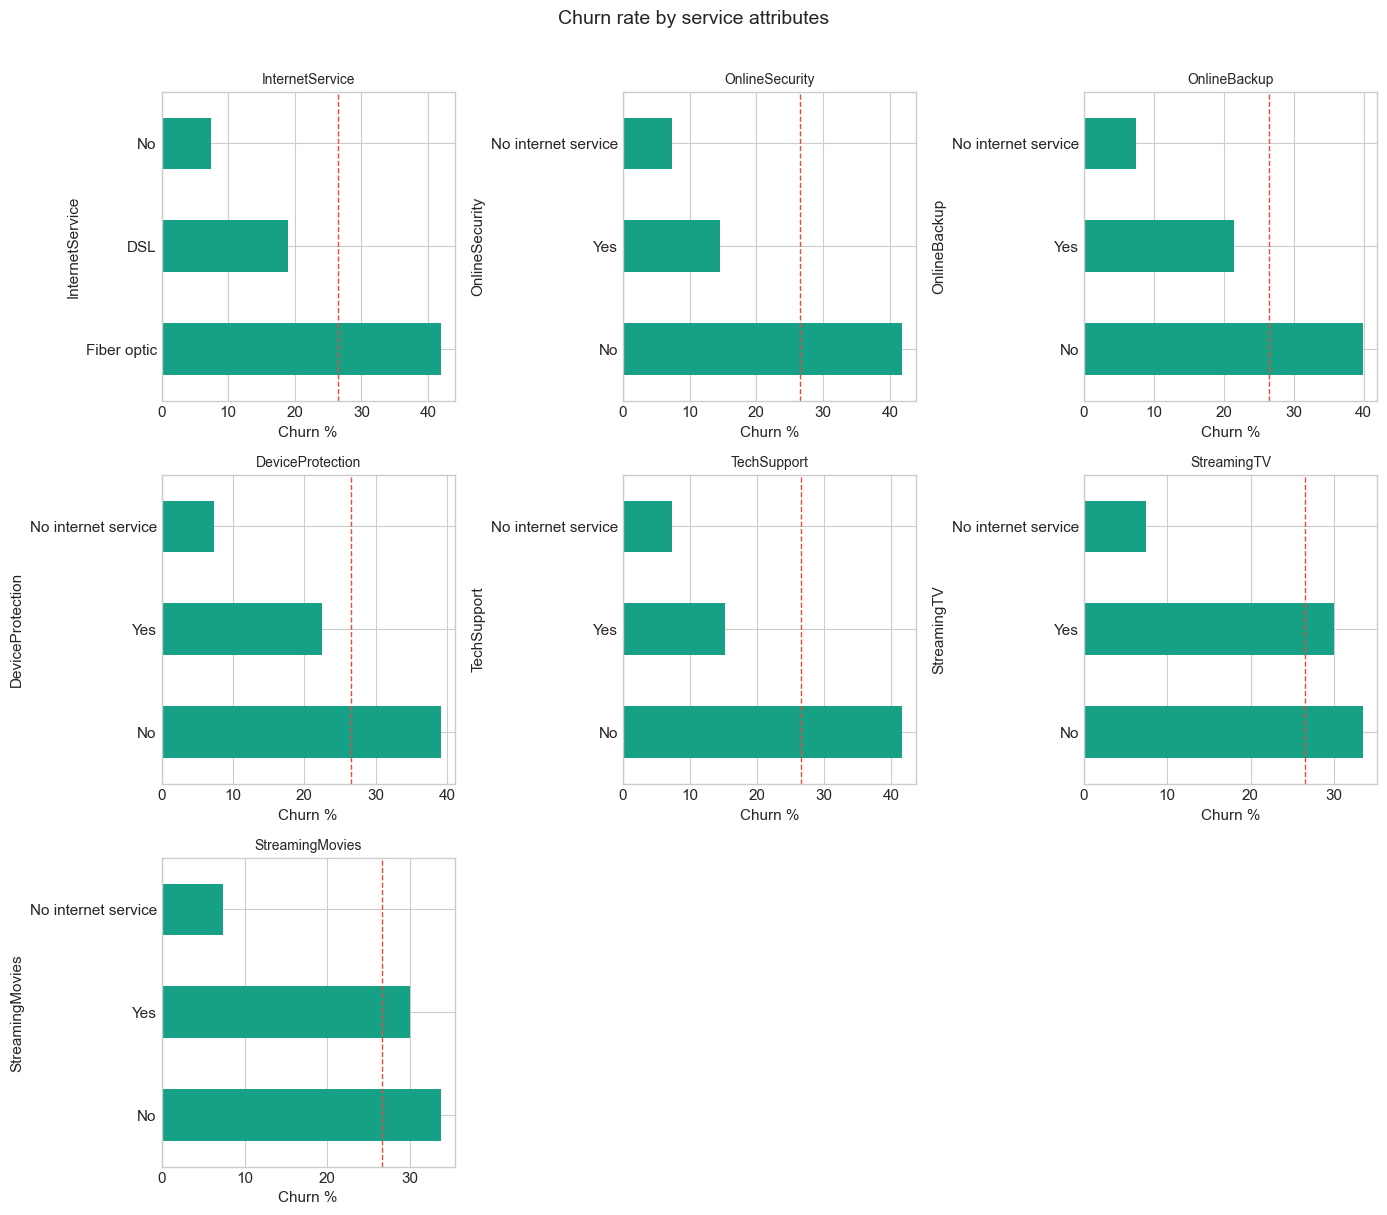

In [27]:
service_cols = [
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.ravel()

for ax, col in zip(axes, service_cols):
    rates = churn_rate_table(df, col)["churn_rate_pct"].sort_values(ascending=False)
    rates.plot(kind="barh", ax=ax, color="#16a085")
    ax.axvline(df["ChurnFlag"].mean() * 100, color="#e74c3c", linestyle="--", linewidth=1)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("Churn %")

# Hide unused subplots
for ax in axes[len(service_cols):]:
    ax.axis("off")

plt.suptitle("Churn rate by service attributes", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### Insights — services

- **Fiber optic** internet is often tied to **higher churn** vs DSL — may reflect competitor fiber builds or expectation gaps.
- Customers **without** Online Security / Tech Support tend to churn more — **support & security** act as retention anchors.
- "No internet service" group behaves differently — mostly phone-only customers.

### Retention actions

- Bundle **security + tech support** for fiber customers in the first year.
- **Competitive save offers** when fiber churn spikes in a zip code (competitive intelligence).

## 9. Correlation analysis

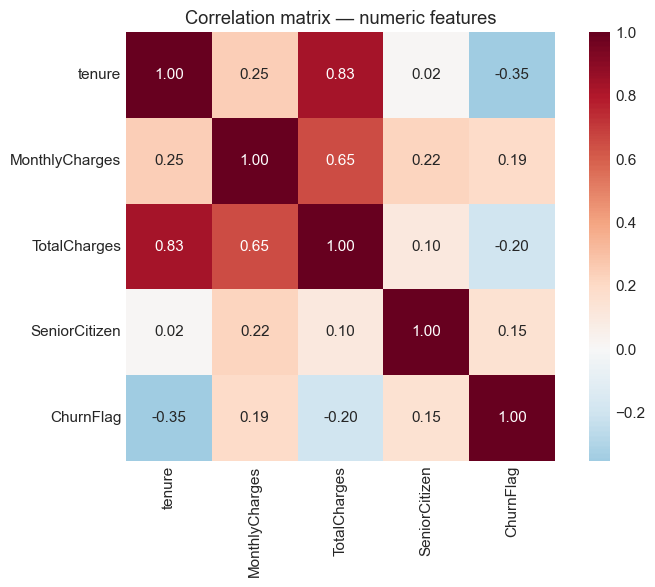

In [28]:
# Numeric features for Pearson correlation
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "ChurnFlag"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, ax=ax)
ax.set_title("Correlation matrix — numeric features")
plt.tight_layout()
plt.show()

In [29]:
# Rank correlations with churn (numeric)
churn_corr = corr["ChurnFlag"].drop("ChurnFlag").sort_values(key=abs, ascending=False)
print("Correlation with ChurnFlag:")
print(churn_corr.round(3))

Correlation with ChurnFlag:
tenure           -0.352
TotalCharges     -0.198
MonthlyCharges    0.193
SeniorCitizen     0.151
Name: ChurnFlag, dtype: float64


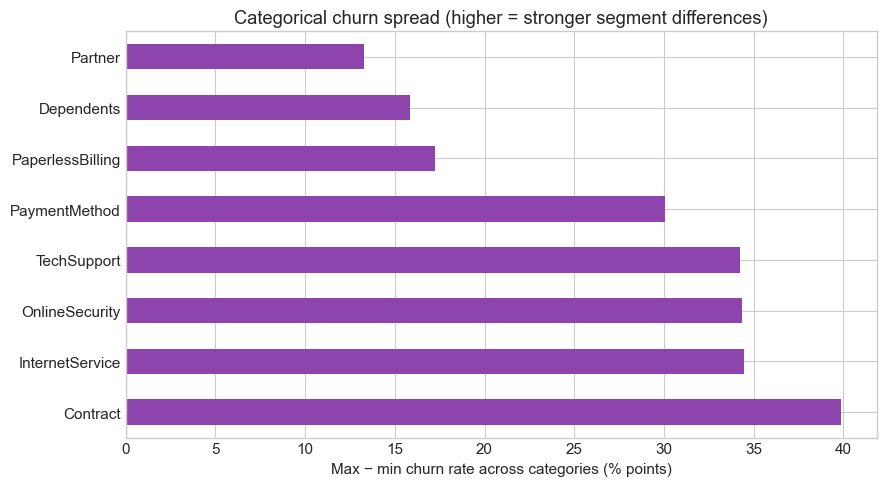

,churn_spread_pp
Contract,39.877819
InternetService,34.487785
OnlineSecurity,34.361744
TechSupport,34.230493
PaymentMethod,30.042311
PaperlessBilling,17.235009
Dependents,15.828904
Partner,13.293076


In [30]:
# Categorical association: churn rate spread (business-friendly "importance")
cat_cols = [
    "Contract", "InternetService", "PaymentMethod", "PaperlessBilling",
    "Partner", "Dependents", "OnlineSecurity", "TechSupport",
]

spreads = {}
for col in cat_cols:
    rates = df.groupby(col)["ChurnFlag"].mean() * 100
    spreads[col] = rates.max() - rates.min()

spread_series = pd.Series(spreads).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
spread_series.plot(kind="barh", ax=ax, color="#8e44ad")
ax.set_xlabel("Max − min churn rate across categories (% points)")
ax.set_title("Categorical churn spread (higher = stronger segment differences)")
plt.tight_layout()
plt.show()

display(spread_series.to_frame("churn_spread_pp"))

### Insights — correlations

- **Tenure** is **negatively** correlated with churn — longer relationships, lower leave probability.
- **MonthlyCharges** is **positively** correlated with churn — higher bills, more risk.
- **TotalCharges** mixes tenure × price; interpret carefully (not independent of tenure).
- **Contract** and **InternetService** show the **largest churn-rate spreads** across categories.

### Retention actions

- Prioritize features with **high spread** in segmentation and modeling (Contract, Internet, Payment).
- Use **tenure + contract** together in CRM rules (e.g., MTM + tenure &lt; 6 months = high risk).

## 10. Churn trends (multi-factor patterns)

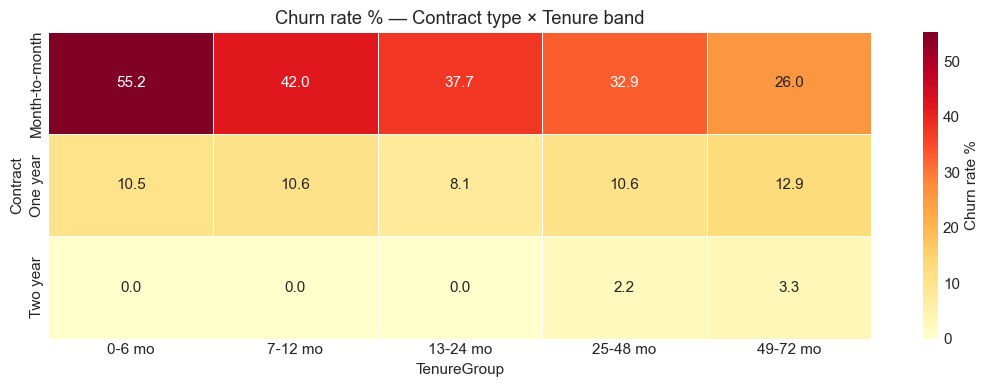

In [31]:
# Heatmap: churn rate by Contract × TenureGroup
pivot_contract_tenure = df.pivot_table(
    index="Contract",
    columns="TenureGroup",
    values="ChurnFlag",
    aggfunc="mean",
    observed=True,
) * 100

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    pivot_contract_tenure.reindex(contract_order),
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Churn rate %"},
)
ax.set_title("Churn rate % — Contract type × Tenure band")
plt.tight_layout()
plt.show()

In [32]:
# High-value at risk: high charges + month-to-month
mrc_threshold = df["MonthlyCharges"].quantile(0.75)
df["HighMRC"] = df["MonthlyCharges"] >= mrc_threshold

risk_segments = (
    df.groupby(["Contract", "HighMRC"], observed=True)
    .agg(customers=("Churn", "size"), churn_rate=("ChurnFlag", "mean"))
    .assign(churn_rate_pct=lambda x: (x["churn_rate"] * 100).round(2))
    .sort_values("churn_rate_pct", ascending=False)
)

print(f"High MRC threshold (75th percentile): ${mrc_threshold:.2f}")
display(risk_segments)

High MRC threshold (75th percentile): $89.85


customers  churn_rate  churn_rate_pct
Contract       HighMRC                                       
Month-to-month True           877    0.519954           52.00
               False         2998    0.399933           39.99
One year       True           449    0.207127           20.71
               False         1024    0.071289            7.13
Two year       True           445    0.069663            6.97
               False         1250    0.013600            1.36

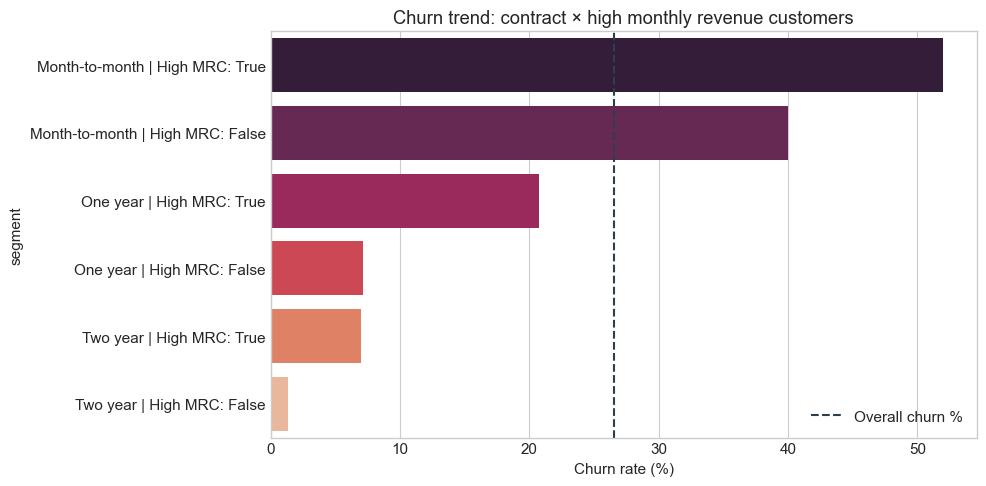

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_data = risk_segments.reset_index()
plot_data["segment"] = plot_data["Contract"] + " | High MRC: " + plot_data["HighMRC"].astype(str)
sns.barplot(data=plot_data, x="churn_rate_pct", y="segment", palette="rocket", ax=ax)
ax.axvline(df["ChurnFlag"].mean() * 100, color="#2c3e50", linestyle="--", label="Overall churn %")
ax.set_xlabel("Churn rate (%)")
ax.set_title("Churn trend: contract × high monthly revenue customers")
ax.legend()
plt.tight_layout()
plt.show()

### Insights — churn trends

- **Month-to-month + low tenure** is typically the **highest-risk cell** in the contract×tenure heatmap.
- **High-MRC month-to-month** customers combine **revenue at risk** with **high churn probability** — prioritize for save desks.
- Long-tenure two-year customers are the **stable core** to protect and use for referrals/upsell.

### Retention actions

- Build a **"red account"** list: `Contract == Month-to-month` AND `tenure < 12` AND `MonthlyCharges > P75`.
- Assign **retention specialists** to high-MRC MTM before competitive offers arrive.

## 11. EDA executive summary (for stakeholders)

In [34]:
overall_churn = df["ChurnFlag"].mean() * 100
top_contract = churn_rate_table(df, "Contract")["churn_rate_pct"].idxmax()
top_payment = churn_rate_table(df, "PaymentMethod")["churn_rate_pct"].idxmax()
median_tenure_churned = df.loc[df["Churn"] == "Yes", "tenure"].median()
median_tenure_stayed = df.loc[df["Churn"] == "No", "tenure"].median()

summary = pd.DataFrame(
    {
        "Metric": [
            "Total customers",
            "Overall churn rate (%)",
            "Highest-risk contract type",
            "Highest-risk payment method",
            "Median tenure — churned (months)",
            "Median tenure — retained (months)",
        ],
        "Value": [
            f"{len(df):,}",
            f"{overall_churn:.2f}",
            top_contract,
            top_payment,
            f"{median_tenure_churned:.0f}",
            f"{median_tenure_stayed:.0f}",
        ],
    }
)

display(summary)

print("\nTop 5 drivers to model and monitor (from EDA):")
print("  1. Contract type (especially month-to-month)")
print("  2. Tenure / customer age on network")
print("  3. Monthly charges / price tier")
print("  4. Payment method (manual vs automatic)")
print("  5. Internet service type & support add-ons")

,Metric,Value
0,Total customers,"7,043"
1,Overall churn rate (%),26.54
2,Highest-risk contract type,Month-to-month
3,Highest-risk payment method,Electronic check
4,Median tenure — churned (months),10
5,Median tenure — retained (months),38



Top 5 drivers to model and monitor (from EDA):
  1. Contract type (especially month-to-month)
  2. Tenure / customer age on network
  3. Monthly charges / price tier
  4. Payment method (manual vs automatic)
  5. Internet service type & support add-ons


## 12. Save EDA summary for SQL / dashboard phase

Exports segment-level churn rates used later in `sql/` queries and Power BI.

In [35]:
eda_export_dir = PROJECT_ROOT / "data" / "processed"
eda_export_dir.mkdir(parents=True, exist_ok=True)

exports = {
    "churn_by_contract.csv": churn_rate_table(df, "Contract"),
    "churn_by_payment.csv": churn_rate_table(df, "PaymentMethod"),
    "churn_by_tenure_band.csv": churn_rate_table(df, "TenureGroup"),
    "churn_by_charge_band.csv": churn_rate_table(df, "ChargeGroup"),
}

for filename, table in exports.items():
    path = eda_export_dir / filename
    table.to_csv(path)
    print(f"Saved {path.name}")

Saved churn_by_contract.csv
Saved churn_by_payment.csv
Saved churn_by_tenure_band.csv
Saved churn_by_charge_band.csv
